# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Regression Discontinuity Design for Top Movers List

---
## Foreword

In this notebook, my goal is to replicate the design of Barber et al. (2022) that demonstrates the influence of the app feature's Top Movers List on the trading behavior of Robinhood's users.


## 1. Libraries & Data

I first load the relevant libraries and data.

In [549]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels import OLS
from linearmodels.panel import PanelOLS
import statsmodels.formula.api as smf

Once the libraries are ready, I import the data.

In [691]:
# baseline trading sample
df = pd.read_csv('../../../data/processed/baseline_trading_sample.csv')

# parse dates
df['date'] = pd.to_datetime(df['date'])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_12899/4266781822.py:2: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../../data/processed/baseline_trading_sample.csv')


In [692]:
assert not df.duplicated(subset=["date", "ticker"]).any(), "df is not unique at the date-ticker level"

In [693]:
# assert that the column 'intraday_userchg' is present in the data frame
assert "intraday_userchg" in df.columns, "intraday_userchg column is not present in the data frame"

In [694]:
# number of unique tickers
num_tickers = df['ticker'].nunique()
print(f"Number of unique tickers: {num_tickers}")

Number of unique tickers: 8272


## 2. Variables Construction

### 2.1. Standard Variables

In this section, I build the relevant variables needed for my analysis.

In [737]:
df = df.sort_values(['ticker', 'date']).copy()

# market cap at market open in millions
df['shrout_lag1'] = df.groupby('ticker')['shrout'].shift(1)
df['mktcap'] = (df['open_price'] * df['shrout_lag1']) / 1e3

# desribe mktcap
print(df['mktcap'].describe())

# overnight return from previous close to today's open
df["close_price_lag"] = df.groupby("ticker")["close_price"].shift(1)
df["overnight_ret"] = (df["open_price"] / df["close_price_lag"]) - 1

# absolute overnight return
df["abs_overnight_ret"] = df["overnight_ret"].abs()

# absolute return
df["abs_ret"] = df['ret'].abs()

# absolute intra ret
df['intra_ret'] = (df['close_price'] / df['open_price']) - 1
df['abs_intra_ret'] = df['intra_ret'].abs()

# rank absolute overnight return within each day
df["abs_overnight_ret_rank"] = df.groupby("date")["abs_overnight_ret"].rank(
    ascending=False, method="first")

# mktcap 
df["gt300"] = (df["mktcap"] > 300).astype(int)
df["gt250"] = (df["mktcap"] > 250).astype(int)

# rank only among stocks above 300
df["abs_overnight_ret_rank_gt300"] = np.nan

tmp300 = (
    df.loc[(df["mktcap"] > 300) & df["abs_overnight_ret"].notna(),
           ["date", "ticker", "abs_overnight_ret"]]
      .sort_values(["date", "abs_overnight_ret", "ticker"], ascending=[True, False, True])
      .copy()
)

tmp300["abs_overnight_ret_rank_gt300"] = tmp300.groupby("date").cumcount() + 1

df = df.merge(
    tmp300[["date", "ticker", "abs_overnight_ret_rank_gt300"]],
    on=["date", "ticker"],
    how="left",
    suffixes=("", "_new")
)

df["abs_overnight_ret_rank_gt300"] = df["abs_overnight_ret_rank_gt300_new"].combine_first(
    df["abs_overnight_ret_rank_gt300"]
)
df = df.drop(columns=["abs_overnight_ret_rank_gt300_new"])

# placebo rank only among stocks above 250
df["abs_overnight_ret_rank_gt250"] = np.nan

tmp250 = (
    df.loc[(df["mktcap"] > 250) & df["abs_overnight_ret"].notna(),
           ["date", "ticker", "abs_overnight_ret"]]
      .sort_values(["date", "abs_overnight_ret", "ticker"], ascending=[True, False, True])
      .copy()
)

tmp250["abs_overnight_ret_rank_gt250"] = tmp250.groupby("date").cumcount() + 1

df = df.merge(
    tmp250[["date", "ticker", "abs_overnight_ret_rank_gt250"]],
    on=["date", "ticker"],
    how="left",
    suffixes=("", "_new")
)

df["abs_overnight_ret_rank_gt250"] = df["abs_overnight_ret_rank_gt250_new"].combine_first(
    df["abs_overnight_ret_rank_gt250"]
)
df = df.drop(columns=["abs_overnight_ret_rank_gt250_new"])

count    3.736584e+06
mean     5.637341e+03
std      3.108109e+04
min      2.000000e-03
25%      9.542111e+01
50%      4.503114e+02
75%      2.274703e+03
max      1.958240e+06
Name: mktcap, dtype: float64


In [699]:
df.columns.tolist()

['date',
 'users_close',
 'users_open',
 'users_11_am',
 'users_2_pm',
 'users_last',
 'intraday_userchg',
 'ticker',
 'permno',
 'ret',
 'prc',
 'vol',
 'shrout',
 'exchcd',
 'symro',
 'symsu',
 'buy_num_trades_LR',
 'sell_num_trades_LR',
 'total_trade_LR',
 'buy_vol_LR',
 'sell_vol_LR',
 'close_price',
 'open_price',
 'close_vol',
 'open_vol',
 'total_vol_m',
 'total_n_trades_m',
 'intra_ret',
 'buy_num_trades_tick',
 'sell_num_trades_tick',
 'buy_vol_tick',
 'sell_vol_tick',
 'total_trade_tick',
 'buy_num_trades_wrds',
 'sell_num_trades_wrds',
 'buy_vol_wrds',
 'sell_vol_wrds',
 'total_trade_wrds',
 'bs_ratio_num',
 'bs_ratio_vol',
 'buy_num_trades_retail',
 'sell_num_trades_retail',
 'buy_vol_retail',
 'sell_vol_retail',
 'total_trade_retail',
 'total_vol_retail',
 'bs_ratio_retail_vol',
 'bs_ratio_retail_num',
 'intra_volatility',
 'buy_num_trades_inst50k',
 'sell_num_trades_inst50k',
 'buy_vol_inst50k',
 'sell_vol_inst50k',
 'total_trade_inst50k',
 'total_vol_inst50k',
 'bs_ratio

### Reproducing Early Findings

I create a plot of the average number of Intraday User change for Robinhood depending on the rank of the return.

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_12899/533045515.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: summarize_cell(x, "userchg_intraday_delayed"))
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_12899/533045515.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: summarize_cell(x, "net_buys"))


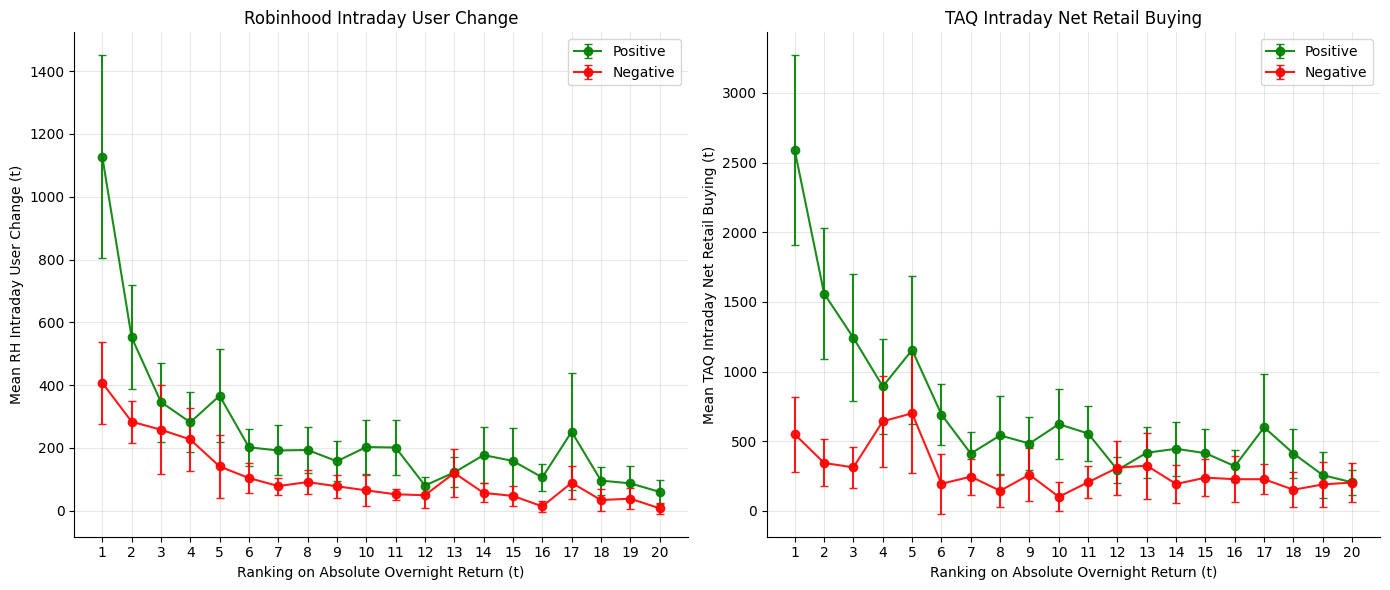

In [743]:
# ------------------------------------------------------------
# 1. PREPARE THE SAMPLE
# ------------------------------------------------------------
df_plot = df.copy()
df_plot['userchg_intra_small'] = df_plot['users_2_pm'] - df_plot['users_open']

# Keep only the variables needed
cols = [
    "date",
    "ticker",
    "mktcap",                      # market cap at market open of day t
    "overnight_ret",               # close(t-1) to open(t)
    "userchg_intraday",            # user change from open to close of day t 
    "userchg_intraday_delayed",      # user change from 11am to close of day t
    "userchg_intra_small",         # user change from open to 2pm of day t
    "net_buys",
    "userchg"                      # user change from open to close of day t
]
df_plot = df_plot[cols].dropna(subset=cols).copy()

# Keep stocks above $300m at the market open
df_plot = df_plot[df_plot["mktcap"] > 300].copy()

# ------------------------------------------------------------
# 2. RANKING BASED ON ABSOLUTE OVERNIGHT RETURN
# ------------------------------------------------------------
df_plot["abs_ret"] = df_plot["overnight_ret"].abs()

# rank 1 = biggest absolute overnight return
df_plot["rank"] = (
    df_plot.groupby("date")["abs_ret"]
           .rank(method="first", ascending=False)
)

# keep top 20
df_plot = df_plot[df_plot["rank"] <= 20].copy()

# sign split
df_plot = df_plot[df_plot["overnight_ret"] != 0].copy()
df_plot["ret_sign"] = np.where(df_plot["overnight_ret"] > 0, "Positive", "Negative")

# ------------------------------------------------------------
# 3. COMPUTE MEANS AND 90% CONFIDENCE INTERVALS
# ------------------------------------------------------------
def summarize_cell(x, value_col):
    n = x[value_col].notna().sum()
    mean = x[value_col].mean()
    se = x[value_col].std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    ci90 = 1.645 * se if pd.notna(se) else np.nan
    return pd.Series({
        "mean": mean,
        "lower": mean - ci90 if pd.notna(ci90) else np.nan,
        "upper": mean + ci90 if pd.notna(ci90) else np.nan,
        "n": n
    })

rh_sum = (
    df_plot.groupby(["rank", "ret_sign"], as_index=False)
           .apply(lambda x: summarize_cell(x, "userchg_intraday_delayed"))
           .reset_index(drop=True)
)

taq_sum = (
    df_plot.groupby(["rank", "ret_sign"], as_index=False)
           .apply(lambda x: summarize_cell(x, "net_buys"))
           .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=False)

for sign, marker, color in [("Positive", "o", "green"), ("Negative", "o", "red")]:
    d1 = rh_sum[rh_sum["ret_sign"] == sign].sort_values("rank")
    axes[0].errorbar(
        d1["rank"], d1["mean"],
        yerr=[d1["mean"] - d1["lower"], d1["upper"] - d1["mean"]],
        fmt=f"-{marker}", capsize=3, label=sign, color=color, alpha=0.9
    )

    d2 = taq_sum[taq_sum["ret_sign"] == sign].sort_values("rank")
    axes[1].errorbar(
        d2["rank"], d2["mean"],
        yerr=[d2["mean"] - d2["lower"], d2["upper"] - d2["mean"]],
        fmt=f"-{marker}", capsize=3, label=sign, color=color, alpha=0.9
    )

axes[0].set_title("Robinhood Intraday User Change")
axes[0].set_xlabel("Ranking on Absolute Overnight Return (t)")
axes[0].set_ylabel("Mean RH Intraday User Change (t)")

axes[1].set_title("TAQ Intraday Net Retail Buying")
axes[1].set_xlabel("Ranking on Absolute Overnight Return (t)")
axes[1].set_ylabel("Mean TAQ Intraday Net Retail Buying (t)")

for ax in axes:
    ax.set_xticks(range(1, 21))
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()

plt.tight_layout()
plt.show()

In [732]:
# identify number of value in userchg below -20000
num_values_below_20000 = (df_plot["userchg"] < -20000).sum()
print(f"Number of values in userchg below -20000: {num_values_below_20000}")

df_plot.loc[df_plot["userchg"] < -20000]


Number of values in userchg below -20000: 2


,date,ticker,mktcap,overnight_ret,userchg_intraday,userchg_intraday_delayed,userchg_intra_small,net_buys,userchg,abs_ret,rank,ret_sign
19872,2020-05-11,ACB,898.65018,11.224538,-8896.0,-3702.0,-8201.0,-3689.0,-548766.0,11.224538,1.0,Positive
3546056,2020-04-29,USO,257.99325,7.455399,-5614.0,-2423.0,-5096.0,-4859.0,-73709.0,7.455399,1.0,Positive


And the regression

In [706]:
# ------------------------------------------------------------
# 6. FORMAL TEST: BARBER ET AL. (2022)-STYLE REGRESSION
# ------------------------------------------------------------
# Work from the same df_plot sample used for the figure
df_reg = df_plot.copy()

# Barber et al. assign:
# 20 = highest absolute return
#  1 = 20th-highest absolute return
df_reg["score"] = 21 - df_reg["rank"]

# Indicator for negative return
df_reg["neg_ret"] = (df_reg["overnight_ret"] < 0).astype(int)

# Keep only needed columns
df_reg = df_reg[[
    "date",
    "ticker",
    "score",
    "neg_ret",
    "userchg_intraday",
    "net_buys"
]].dropna().copy()

# Make sure date is a datetime
df_reg["date"] = pd.to_datetime(df_reg["date"])

# ------------------------------------------------------------
# 6A. ROBINHOOD REGRESSION
# NetBuy_it = beta0 + beta1*Score_it + beta2*I(R_it<0)
#           + beta3*Score_it*I(R_it<0) + alpha_t + epsilon_it
# ------------------------------------------------------------
rh_mod = smf.ols(
    formula="userchg_intraday ~ score + neg_ret + score:neg_ret + C(date)",
    data=df_reg
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["date"]}
)

# ------------------------------------------------------------
# 6B. TAQ REGRESSION
# ------------------------------------------------------------
taq_mod = smf.ols(
    formula="net_buys ~ score + neg_ret + score:neg_ret + C(date)",
    data=df_reg
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["date"]}
)

# ------------------------------------------------------------
# 6C. DISPLAY MAIN COEFFICIENTS
# ------------------------------------------------------------
coef_table = pd.DataFrame({
    "RH coef": rh_mod.params[["score", "neg_ret", "score:neg_ret"]],
    "RH se": rh_mod.bse[["score", "neg_ret", "score:neg_ret"]],
    "RH pval": rh_mod.pvalues[["score", "neg_ret", "score:neg_ret"]],
    "TAQ coef": taq_mod.params[["score", "neg_ret", "score:neg_ret"]],
    "TAQ se": taq_mod.bse[["score", "neg_ret", "score:neg_ret"]],
    "TAQ pval": taq_mod.pvalues[["score", "neg_ret", "score:neg_ret"]],
})

print("\nBarber et al. (2022)-style top-mover regression results")
print(coef_table.round(4))


Barber et al. (2022)-style top-mover regression results
                RH coef    RH se  RH pval  TAQ coef    TAQ se  TAQ pval
score           49.1597   6.2208   0.0000   69.6042    9.9218    0.0000
neg_ret        122.3286  56.0080   0.0290  344.3924  101.6926    0.0007
score:neg_ret  -23.8011   6.8131   0.0005  -52.2120   11.1369    0.0000


In both the Robinhood and TAQ samples, buying activity increases monotonically with top-mover score, indicating that investors concentrate their purchases in the most extreme movers. However, the response is significantly weaker for negative-return stocks, as shown by the negative and highly significant interaction between score and the negative-return indicator. This asymmetry is materially larger in the TAQ sample than in the Robinhood sample, implying that Robinhood users are less averse than other retail investors to buying top losers.

I further create the RD running-variable terms:

In [707]:
for c in [250, 300]:
    df[f"mktcap1_{c}"] = df["mktcap"] - c
    df[f"mktcap2_{c}"] = (df["mktcap"] - c) ** 2
    df[f"mktcap3_{c}"] = (df["mktcap"] - c) ** 3

### 2.2. Build Matched RD Samples

For each bandwidth $b$:

+ keep stocks with `rank_absret` $\leq 80$
+ treated = gt300 == 1 and `rank_absret_gt300` $\leq$ 20
+ controls = stocks below 300 within the bandwidth
+ match on same day using closest absolute overnight return distance
+ impose $0.5 \le |R^{treat}|/|R^{control}| \le 2$ or the inverse equivalent depending on my ratio definition 

In [708]:
def build_matched_rd_sample(df, bandwidth, cutoff=300):
    x = df.copy()

    # assert that the column 'intraday_userchg' is present in the data frame
    assert "intraday_userchg" in x.columns, "intraday_userchg column is not present in the data frame"

    x = x.loc[
        x["intraday_userchg"].notna() &
        x["abs_overnight_ret_rank"].notna() &
        (x["abs_overnight_ret_rank"] <= 80) &
        ((x["mktcap"] - cutoff).abs() < bandwidth)
    ].copy()

    treated = x.loc[
        (x[f"gt{cutoff}"] == 1) &
        (x[f"abs_overnight_ret_rank_gt{cutoff}"] <= 20)
    ].copy()

    controls = x.loc[
        (x["mktcap"] >= cutoff - bandwidth) &
        (x["mktcap"] <= cutoff)
    ].copy()

    out = []

    for dt, g1 in treated.groupby("date"):
        g0 = controls.loc[controls["date"] == dt].copy()
        if g0.empty:
            continue

        used = set()

        for _, tr in g1.iterrows():
            pool = g0.loc[~g0.index.isin(used)].copy()
            if pool.empty:
                continue

            ratio = tr["abs_overnight_ret"] / pool["abs_overnight_ret"].replace(0, np.nan)
            pool = pool.loc[(ratio >= 0.5) & (ratio <= 2)].copy()
            if pool.empty:
                continue

            pool["abs_ret_diff"] = (pool["abs_overnight_ret"] - tr["abs_overnight_ret"]).abs()
            best_idx = pool["abs_ret_diff"].idxmin()
            used.add(best_idx)

            ctrl = g0.loc[[best_idx]].copy()
            out.append(tr.to_frame().T)
            out.append(ctrl)

    if not out:
        return pd.DataFrame()

    matched = pd.concat(out, ignore_index=True)
    return matched

Once this is done, I estimate the pooled sharp RD used in Table VII.

In [709]:
import statsmodels.formula.api as smf

def run_rd(matched, cutoff=300):
    f1 = f"intraday_userchg ~ gt{cutoff} * mktcap1_{cutoff}"
    f2 = f"intraday_userchg ~ gt{cutoff} * mktcap1_{cutoff} + gt{cutoff} * mktcap2_{cutoff}"
    f3 = f"intraday_userchg ~ gt{cutoff} * mktcap1_{cutoff} + gt{cutoff} * mktcap2_{cutoff} + gt{cutoff} * mktcap3_{cutoff}"

    m1 = smf.ols(f1, data=matched).fit(cov_type="cluster", cov_kwds={"groups": matched["date"]})
    m2 = smf.ols(f2, data=matched).fit(cov_type="cluster", cov_kwds={"groups": matched["date"]})
    m3 = smf.ols(f3, data=matched).fit(cov_type="cluster", cov_kwds={"groups": matched["date"]})

    return m1, m2, m3

The paper also runs balance check on absolute overnight returns. The paper does this to verify there is no discontinuity in matched overnight-return magnitudes at the $300 million cutoff.

In [710]:
def run_balance(matched, cutoff=300):
    f1 = f"abs_overnight_ret ~ gt{cutoff} * mktcap1_{cutoff}"
    f2 = f"abs_overnight_ret ~ gt{cutoff} * mktcap1_{cutoff} + gt{cutoff} * mktcap2_{cutoff}"
    f3 = f"abs_overnight_ret ~ gt{cutoff} * mktcap1_{cutoff} + gt{cutoff} * mktcap2_{cutoff} + gt{cutoff} * mktcap3_{cutoff}"

    b1 = smf.ols(f1, data=matched).fit(cov_type="cluster", cov_kwds={"groups": matched["date"]})
    b2 = smf.ols(f2, data=matched).fit(cov_type="cluster", cov_kwds={"groups": matched["date"]})
    b3 = smf.ols(f3, data=matched).fit(cov_type="cluster", cov_kwds={"groups": matched["date"]})

    return b1, b2, b3

## 3. Regresssions

I now run the same regressions as in Barber et al. (2022).

In [711]:
matched = build_matched_rd_sample(df, bandwidth=50, cutoff=300).copy()

print(matched["intraday_userchg"].dtype)
print(matched["intraday_userchg"].head())
print(matched["intraday_userchg"].apply(type).value_counts().head(10))

object
0    126.0
1     74.0
2     -1.0
3     16.0
4     25.0
Name: intraday_userchg, dtype: object
intraday_userchg
<class 'float'>    686
Name: count, dtype: int64


In [712]:
def estimate_table_vii(day_df, bandwidths=(50, 75, 100, 125), cutoff=300):
    rows = []

    depvar = "intraday_userchg"
    treat = f"gt{cutoff}"
    x1 = f"mktcap1_{cutoff}"
    x2 = f"mktcap2_{cutoff}"
    x3 = f"mktcap3_{cutoff}"

    for bw in bandwidths:
        matched = build_matched_rd_sample(day_df, bandwidth=bw, cutoff=cutoff).copy()
        if matched.empty:
            continue

        cluster_var = "tday" if "tday" in matched.columns else "date"

        needed = [depvar, treat, x1, x2, x3, cluster_var]
        missing = [c for c in needed if c not in matched.columns]
        if missing:
            raise KeyError(f"Missing columns in matched sample: {missing}")

        for c in [depvar, treat, x1, x2, x3]:
            matched[c] = pd.to_numeric(matched[c], errors="coerce")

        matched = matched.dropna(subset=[depvar, treat, x1, cluster_var]).copy()

        formulas = {
            "linear":    f"{depvar} ~ {treat} * {x1}",
            "quadratic": f"{depvar} ~ {treat} * {x1} + {treat} * {x2}",
            "cubic":     f"{depvar} ~ {treat} * {x1} + {treat} * {x2} + {treat} * {x3}",
        }

        for spec, formula in formulas.items():
            model = smf.ols(formula, data=matched).fit(
                cov_type="cluster",
                cov_kwds={"groups": matched[cluster_var]}
            )

            rows.append({
                "bandwidth": bw,
                "spec": spec,
                f"coef_gt{cutoff}": model.params.get(treat, np.nan),
                f"se_gt{cutoff}": model.bse.get(treat, np.nan),
                f"p_gt{cutoff}": model.pvalues.get(treat, np.nan),
                "nobs": int(model.nobs),
                "r2": model.rsquared,
                "model": model
            })

    return pd.DataFrame(rows)

In [713]:
table_vii = estimate_table_vii(df, bandwidths=(50, 75, 100, 125), cutoff=300)

table_vii_display = table_vii.drop(columns="model").copy()
print(table_vii_display)

    bandwidth       spec  coef_gt300    se_gt300   p_gt300  nobs        r2
0          50     linear  -93.876679  197.737003  0.634961   686  0.002269
1          50  quadratic -402.027387  232.939156  0.084367   686  0.005780
2          50      cubic -154.508544  184.110301  0.401347   686  0.007765
3          75     linear -149.183761  124.764375  0.231804  1204  0.002545
4          75  quadratic -170.579797  191.807495  0.373827  1204  0.003176
5          75      cubic -360.239798  205.616783  0.079774  1204  0.004549
6         100     linear -179.473941  126.330566  0.155413  1800  0.005502
7         100  quadratic -276.521784  202.579302  0.172251  1800  0.005972
8         100      cubic -332.386303  301.395056  0.270103  1800  0.006387
9         125     linear -125.802620  108.851984  0.247795  2332  0.003864
10        125  quadratic -249.316057  189.057424  0.187259  2332  0.004620
11        125      cubic -273.022302  275.274184  0.321286  2332  0.004649


I also realize the plots.

In [714]:
def fit_rd_model(matched, spec="linear", cutoff=300):
    cluster_var = "tday" if "tday" in matched.columns else "date"

    formulas = {
        "linear":    f"intraday_userchg ~ gt{cutoff} * mktcap1_{cutoff}",
        "quadratic": f"intraday_userchg ~ gt{cutoff} * mktcap1_{cutoff} + gt{cutoff} * mktcap2_{cutoff}",
        "cubic":     f"intraday_userchg ~ gt{cutoff} * mktcap1_{cutoff} + gt{cutoff} * mktcap2_{cutoff} + gt{cutoff} * mktcap3_{cutoff}",
    }

    model = smf.ols(formulas[spec], data=matched).fit(
        cov_type="cluster",
        cov_kwds={"groups": matched[cluster_var]}
    )
    return model

In [715]:
def make_binned_scatter_by_side(df, x="mktcap", y="intraday_userchg", cutoff=300, bins_per_side=10):
    out = []

    left = df[df[x] <= cutoff].copy()
    right = df[df[x] > cutoff].copy()

    for side_df, side_name in [(left, "left"), (right, "right")]:
        if side_df.empty:
            continue

        # equal-width bins within each side
        side_df = side_df.copy()
        side_df["bin"] = pd.cut(side_df[x], bins=bins_per_side, duplicates="drop")

        grouped = (
            side_df.groupby("bin", observed=True)
            .agg(
                x_mean=(x, "mean"),
                y_mean=(y, "mean"),
                n=(y, "size")
            )
            .reset_index(drop=True)
        )
        grouped["side"] = side_name
        out.append(grouped)

    return pd.concat(out, ignore_index=True)

In [716]:
def build_prediction_grid(matched, spec="linear", cutoff=300, ngrid=300):
    left = matched.loc[matched["mktcap"] <= cutoff, "mktcap"]
    right = matched.loc[matched["mktcap"] > cutoff, "mktcap"]

    grids = []

    if len(left) > 0:
        x_left = np.linspace(left.min(), left.max(), ngrid)
        g_left = pd.DataFrame({"mktcap": x_left})
        g_left[f"gt{cutoff}"] = 0
        g_left[f"mktcap1_{cutoff}"] = g_left["mktcap"] - cutoff
        g_left[f"mktcap2_{cutoff}"] = (g_left["mktcap"] - cutoff) ** 2
        g_left[f"mktcap3_{cutoff}"] = (g_left["mktcap"] - cutoff) ** 3
        g_left["side"] = "left"
        grids.append(g_left)

    if len(right) > 0:
        x_right = np.linspace(right.min(), right.max(), ngrid)
        g_right = pd.DataFrame({"mktcap": x_right})
        g_right[f"gt{cutoff}"] = 1
        g_right[f"mktcap1_{cutoff}"] = g_right["mktcap"] - cutoff
        g_right[f"mktcap2_{cutoff}"] = (g_right["mktcap"] - cutoff) ** 2
        g_right[f"mktcap3_{cutoff}"] = (g_right["mktcap"] - cutoff) ** 3
        g_right["side"] = "right"
        grids.append(g_right)

    return pd.concat(grids, ignore_index=True)

In [717]:
def add_predictions(model, grid, alpha=0.10):
    pred = model.get_prediction(grid).summary_frame(alpha=alpha).reset_index(drop=True)
    out = grid.copy().reset_index(drop=True)
    out["fit"] = pred["mean"]
    out["ci_low"] = pred["mean_ci_lower"]
    out["ci_high"] = pred["mean_ci_upper"]
    return out

In [718]:
def plot_figure5_panel(day_df, spec="linear", bandwidth=50, cutoff=300, bins_per_side=10):
    matched = build_matched_rd_sample(day_df, bandwidth=bandwidth, cutoff=cutoff).copy()
    if matched.empty:
        raise ValueError("Matched sample is empty.")
    
    # convert relevant columns to numeric, coercing errors to NaN
    for c in ["intraday_userchg", "mktcap", f"mktcap1_{cutoff}", f"mktcap2_{cutoff}", f"mktcap3_{cutoff}", f"gt{cutoff}"]:
        matched[c] = pd.to_numeric(matched[c], errors="coerce")

    model = fit_rd_model(matched, spec=spec, cutoff=cutoff)

    bins = make_binned_scatter_by_side(
        matched, x="mktcap", y="intraday_userchg", cutoff=cutoff, bins_per_side=bins_per_side
    )

    grid = build_prediction_grid(matched, spec=spec, cutoff=cutoff, ngrid=300)
    pred = add_predictions(model, grid, alpha=0.10)

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    # binned scatter
    ax.scatter(
        bins["x_mean"],
        bins["y_mean"],
        s=35,
        color=bins["side"].map({"left": "blue", "right": "green"}),
        alpha=0.8,
        label="Binned means"
    )

    # fitted lines + 90% CI, separately by side
    for side in ["left", "right"]:
        p = pred[pred["side"] == side].sort_values("mktcap")
        if p.empty:
            continue

        ax.plot(
            p["mktcap"],
            p["fit"],
            color="red",
            linewidth=1.5
        )
        ax.fill_between(
            p["mktcap"],
            p["ci_low"],
            p["ci_high"],
            color="grey",
            alpha=0.18
        )

    ax.axvline(cutoff, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Market cap at market open ($ millions)")
    ax.set_ylabel("Robinhood intraday user change")
    ax.set_title(f"{spec.capitalize()} fit", fontsize=14, pad=15, family="Times New Roman", loc="center")
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    return matched, model, bins, pred

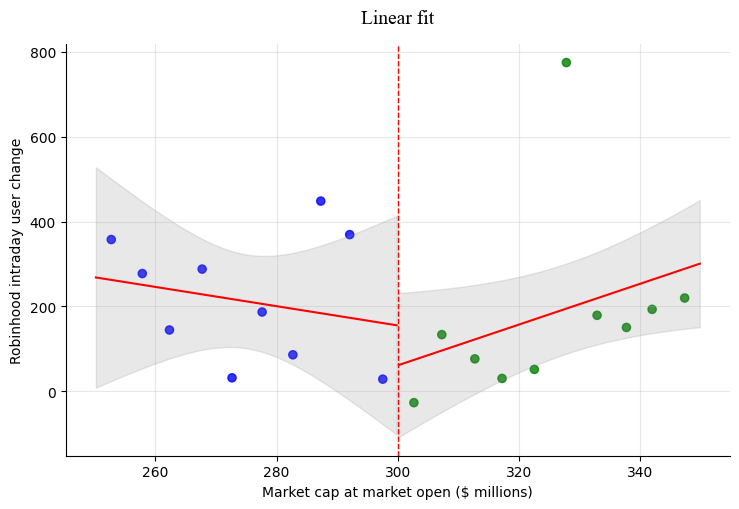

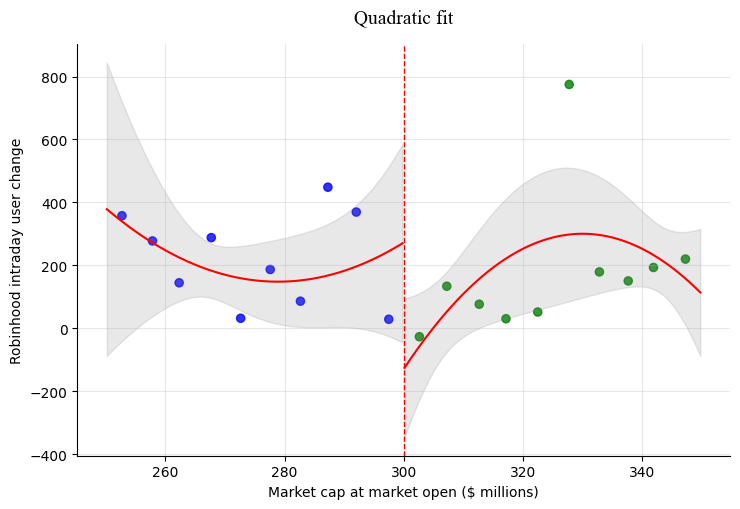

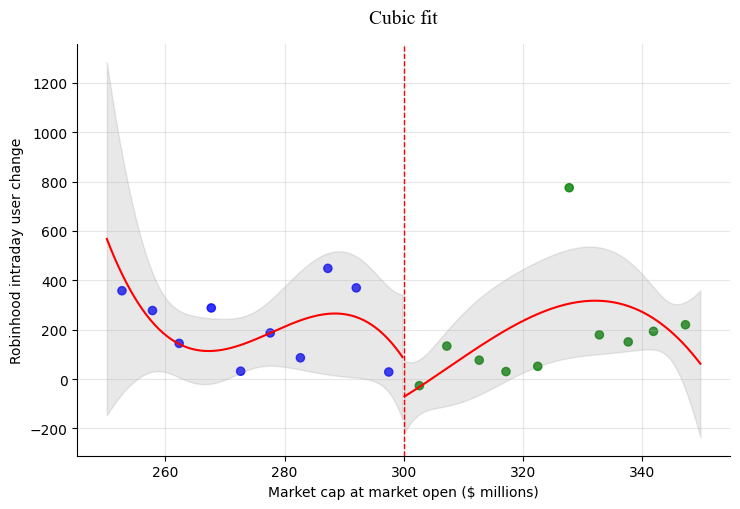

(                    date users_close users_open users_11_am users_2_pm  \
 0    2018-05-10 00:00:00      2124.0     1998.0      2076.0     2105.0   
 1    2018-05-10 00:00:00      1254.0     1180.0      1220.0     1243.0   
 2    2018-05-10 00:00:00       410.0      411.0       411.0      411.0   
 3    2018-05-10 00:00:00       366.0      350.0       356.0      364.0   
 4    2018-05-14 00:00:00      1063.0     1038.0      1053.0     1059.0   
 ..                   ...         ...        ...         ...        ...   
 681  2020-08-04 00:00:00       488.0      491.0       490.0      490.0   
 682  2020-08-04 00:00:00      1135.0      532.0      1006.0     1118.0   
 683  2020-08-04 00:00:00      1743.0     1851.0      1784.0     1747.0   
 684  2020-08-11 00:00:00     88163.0    88531.0     88286.0    88140.0   
 685  2020-08-11 00:00:00    137789.0   137709.0    137742.0   137708.0   
 
     users_last  intraday_userchg ticker   permno       ret  ... gt300 gt250  \
 0       2132.0   

In [719]:
plot_figure5_panel(df, spec="linear", bandwidth=50, cutoff=300, bins_per_side=10)
plot_figure5_panel(df, spec="quadratic", bandwidth=50, cutoff=300, bins_per_side=10)
plot_figure5_panel(df, spec="cubic", bandwidth=50, cutoff=300, bins_per_side=10)

## 4. Further Steps

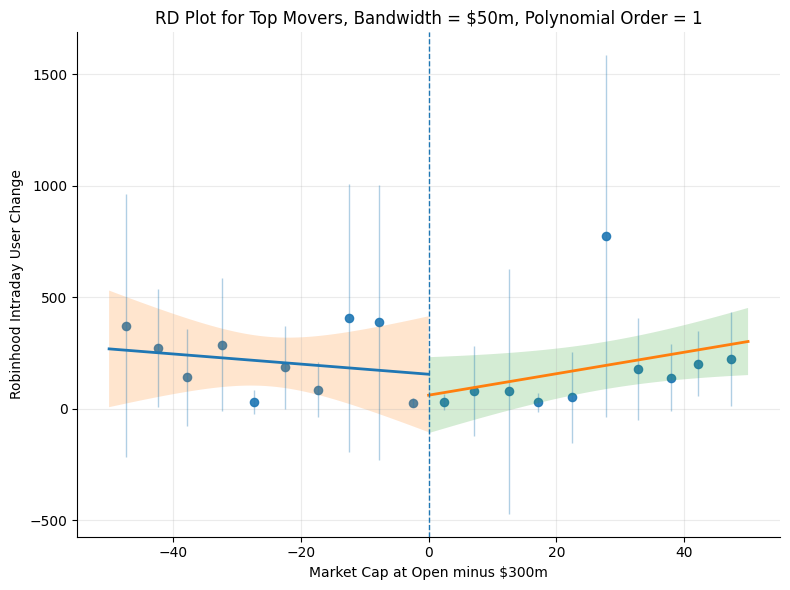

                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       155.2328    157.803      0.984      0.325    -154.056     464.521
above           -93.8767    197.737     -0.475      0.635    -481.434     293.681
running          -2.2716      5.733     -0.396      0.692     -13.507       8.964
above:running     7.0819      6.046      1.171      0.241      -4.768      18.932


In [720]:
# ------------------------------------------------------------
# 1. INPUT: matched RD sample
# ------------------------------------------------------------
# Assumptions:
# matched contains the matched RD sample for one bandwidth
# with columns:
#   date
#   ticker
#   mktcap                market cap at market open of day t, in $ millions
#   intraday_userchg      RH intraday user change on day t
# and already includes:
#   treated / larger_than_300 indicator if desired
#
# This sample should contain:
#   - treated stocks: top-20 overnight movers with mktcap in (300, 300+bw]
#   - matched controls: below-cutoff stocks in [300-bw, 300]
# matched on abs overnight return

matched = build_matched_rd_sample(df, bandwidth=50, cutoff=300)
df_rd = matched.copy()

# convert to numeric, coercing errors to NaN
for c in ["intraday_userchg", "mktcap"]:
    df_rd[c] = pd.to_numeric(df_rd[c], errors="coerce")

# running variable centered at cutoff
df_rd["running"] = df_rd["mktcap"] - 300
df_rd["above"] = (df_rd["mktcap"] > 300).astype(int)

# keep one bandwidth explicitly, e.g. 50
bw = 50
df_rd = df_rd[df_rd["running"].between(-bw, bw)].copy()

# ------------------------------------------------------------
# 2. BINNED SCATTER DATA
# ------------------------------------------------------------
# Barber's figure is a binned scatterplot. Use equal-width bins.
bin_width = 5   # $5m bins; you can also try 4 or 2.5
bins = np.arange(-bw, bw + bin_width, bin_width)

df_rd["bin"] = pd.cut(df_rd["running"], bins=bins, include_lowest=True)

bin_means = (
    df_rd.groupby("bin", observed=True)
         .agg(
             running_mean=("running", "mean"),
             y_mean=("intraday_userchg", "mean"),
             n=("intraday_userchg", "size"),
             y_sd=("intraday_userchg", "std")
         )
         .reset_index(drop=True)
)

bin_means["se"] = bin_means["y_sd"] / np.sqrt(bin_means["n"])
bin_means["ci90"] = 1.645 * bin_means["se"]
bin_means["lower"] = bin_means["y_mean"] - bin_means["ci90"]
bin_means["upper"] = bin_means["y_mean"] + bin_means["ci90"]

# ------------------------------------------------------------
# 3. LOCAL POLYNOMIAL FITS SEPARATELY LEFT AND RIGHT
# ------------------------------------------------------------
# order = 1, 2, or 3 to mimic Panels A/B/C of Figure 5
order = 1

# build polynomial terms
for p in range(2, order + 1):
    df_rd[f"running{p}"] = df_rd["running"] ** p

# formula with separate slope/polynomial on each side
rhs_terms = ["above", "running"]
for p in range(2, order + 1):
    rhs_terms.append(f"running{p}")

# interactions with above
rhs_terms += [f"above:running"]
for p in range(2, order + 1):
    rhs_terms.append(f"above:running{p}")

formula = "intraday_userchg ~ " + " + ".join(rhs_terms)

rd_mod = smf.ols(formula, data=df_rd).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_rd["date"]}
)

# prediction grid
grid_left = pd.DataFrame({"running": np.linspace(-bw, 0, 200)})
grid_left["above"] = 0

grid_right = pd.DataFrame({"running": np.linspace(0, bw, 200)})
grid_right["above"] = 1

for p in range(2, order + 1):
    grid_left[f"running{p}"] = grid_left["running"] ** p
    grid_right[f"running{p}"] = grid_right["running"] ** p

pred_left = rd_mod.get_prediction(grid_left).summary_frame(alpha=0.10)
pred_right = rd_mod.get_prediction(grid_right).summary_frame(alpha=0.10)

# ------------------------------------------------------------
# 4. PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# binned means
ax.scatter(
    bin_means["running_mean"],
    bin_means["y_mean"],
    s=35,
    alpha=0.9
)

# optional bin CI bars
ax.vlines(
    bin_means["running_mean"],
    bin_means["lower"],
    bin_means["upper"],
    alpha=0.35,
    linewidth=1
)

# fitted line left of cutoff
ax.plot(grid_left["running"], pred_left["mean"], linewidth=2)
ax.fill_between(
    grid_left["running"],
    pred_left["mean_ci_lower"],
    pred_left["mean_ci_upper"],
    alpha=0.2
)

# fitted line right of cutoff
ax.plot(grid_right["running"], pred_right["mean"], linewidth=2)
ax.fill_between(
    grid_right["running"],
    pred_right["mean_ci_lower"],
    pred_right["mean_ci_upper"],
    alpha=0.2
)

# cutoff
ax.axvline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Market Cap at Open minus $300m")
ax.set_ylabel("Robinhood Intraday User Change")
ax.set_title(f"RD Plot for Top Movers, Bandwidth = ${bw}m, Polynomial Order = {order}")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# coefficient on discontinuity
print(rd_mod.summary().tables[1])